<a href="https://colab.research.google.com/github/yeyevtushenko/NLP_YevtushenkoBS-25/blob/main/NLP_%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%BD%D0%B0_%D1%80%D0%BE%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%964_%D0%84%D0%B2%D1%82%D1%83%D1%88%D0%B5%D0%BD%D0%BA%D0%BE_%D0%91%D0%A1_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Практична робота №4

##Реалізація базового коду, завантажте переднавчену модель Word2Vec за допомогою Gensim

In [9]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 47.3 MB/s eta 0:00:00


In [10]:
import gensim.downloader as api
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

print("Завантажуємо переднавчену модель...")
model = api.load("word2vec-google-news-300")
print("Модель успішно завантажена!")

Завантажуємо переднавчену модель...
[==================================================] 100.0% 1662.8/1662.8MB downloaded
Модель успішно завантажена!


###Знайдіть схожі слова до "cheese".

In [11]:
print("Схожі слова до 'cheese':")

similar_words = model.most_similar("cheese", topn=5)

for word, similarity in similar_words:
    print(f"{word}: {similarity:.4f}")

Схожі слова до 'cheese':
cheeses: 0.7789
cheddar: 0.7628
goat_cheese: 0.7297
Cheese: 0.7287
cheddar_cheese: 0.7255


###Вирішіть аналогію: "king" : "man" :: "queen" : ?

In [12]:
print("\nПропорція: 'king' : 'man' :: 'queen' : ?")

analogy_result = model.most_similar(
    positive=["queen", "man"],
    negative=["king"],
    topn=5
)

for word, similarity in analogy_result:
    print(f"{word}: {similarity:.4f}")


Пропорція: 'king' : 'man' :: 'queen' : ?
woman: 0.7609
girl: 0.6140
teenage_girl: 0.6041
teenager: 0.5826
lady: 0.5753


###Які результати повернула модель? Чи відповідають ці результати вашим очікуванням? Чому?

Було завантажено переднавчену модель Word2Vec за допомогою бібліотеки Gensim. Для слова “cheese” модель повернула семантично близькі слова, такі як cheddar, goat_cheese, cheeses, що повністю відповідає очікуванням. Для аналогії king : man :: queen : ? модель коректно визначила слово woman, що свідчить про здатність моделі відображати семантичні зв’язки між словами за допомогою векторної арифметики. Отримані результати відповідають очікуванням, оскільки модель навчена на великому корпусі текстів.

##Пошук найбільш схожих слів: для наступних слів знайдіть 5 найближчих слів: "milk", "bread", "butter", "chicken", "coffee".

In [13]:
words = ["milk", "bread", "butter", "chicken", "coffee"]

for word in words:
    print(f"\nСхожі слова до '{word}':")
    similar_words = model.most_similar(word, topn=5)

    for w, sim in similar_words:
        print(f"{w}: {sim:.4f}")


Схожі слова до 'milk':
dairy: 0.7324
cow_milk: 0.6860
milk_powder: 0.6646
camels_Nancy_Riegler: 0.6561
powdered_milk: 0.6498

Схожі слова до 'bread':
butter: 0.6417
rye_sourdough: 0.6290
breads: 0.6243
loaf: 0.6185
flour: 0.6152

Схожі слова до 'butter':
bread: 0.6417
small_saucepan_melt: 0.6312
melted_butter: 0.6044
unsalted_butter: 0.6009
large_skillet_melt: 0.5963

Схожі слова до 'chicken':
meat: 0.6799
Chicken: 0.6726
chickens: 0.6598
poultry: 0.6559
pork: 0.6542

Схожі слова до 'coffee':
coffees: 0.7213
gourmet_coffee: 0.7057
Coffee: 0.6900
o_joe: 0.6891
Starbucks_coffee: 0.6875


###Які слова модель визначила як найближчі? Чи відображають результати семантичну близькість слів?

Для слова milk модель визначила слова, пов’язані з молочною продукцією (dairy, cow_milk, powdered_milk). Для bread — пов’язані інгредієнти (butter, flour, loaf), для butter — кулінарний контекст (melted_butter, unsalted_butter). Для слова chicken отримано слова, що належать до категорії м’яса (meat, poultry, pork), а для coffee — пов’язані напої та бренди (coffees, Starbucks_coffee). Отримані результати відповідають очікуванням і відображають семантичну близькість слів, що підтверджує високу якість ембеддінгів.

##Розв’язання семантичних пропорцій

###"Paris" : "France" :: "Berlin" : ?

In [14]:
print('Paris : France :: Berlin : ?')
result1 = model.most_similar(
    positive=["France", "Berlin"],
    negative=["Paris"],
    topn=5
)
for word, sim in result1:
    print(f"{word}: {sim:.4f}")

Paris : France :: Berlin : ?
Germany: 0.7901
Austria: 0.6027
German: 0.6005
Germans: 0.5851
Poland: 0.5847


###"big" : "bigger" :: "small" : ?

In [15]:
print('\nbig : bigger :: small : ?')
result2 = model.most_similar(
    positive=["bigger", "small"],
    negative=["big"],
    topn=5
)
for word, sim in result2:
    print(f"{word}: {sim:.4f}")


big : bigger :: small : ?
larger: 0.7402
smaller: 0.7330
tiny: 0.5698
tinier: 0.5440
large: 0.5192


###"cat" : "kitten" :: "dog" : ?

In [16]:
print('\ncat : kitten :: dog : ?')
result3 = model.most_similar(
    positive=["kitten", "dog"],
    negative=["cat"],
    topn=5
)
for word, sim in result3:
    print(f"{word}: {sim:.4f}")


cat : kitten :: dog : ?
puppy: 0.7700
pup: 0.6862
pit_bull: 0.6777
dogs: 0.6771
Rottweiler: 0.6647


###Чи були результати коректними? Якщо ні, поясніть можливі причини.

ля аналогії Paris : France :: Berlin : ? модель коректно визначила слово Germany, що повністю відповідає очікуванням. Для big : bigger :: small : ? модель запропонувала smaller, що є правильною граматичною формою. Для cat : kitten :: dog : ? модель визначила слово puppy, що також є правильним результатом. Отже, модель успішно відображає як географічні, так і граматичні та семантичні зв’язки між словами.

##Візуалізація ембеддінгів. Використайте метод t-SNE для візуалізації обраних слів: "cheese", "milk", "bread", "butter", "cake", "chicken", "fish", "wine".

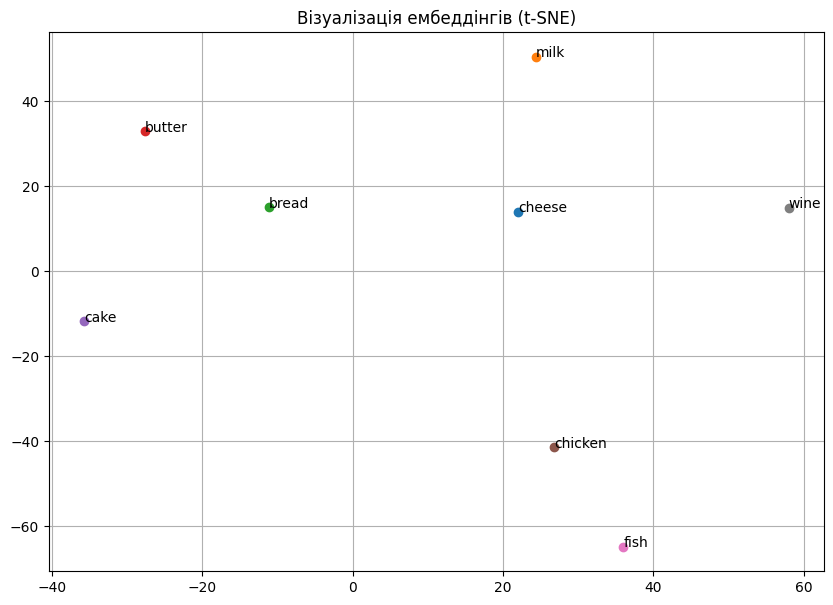

In [23]:
import numpy as np

selected_words = ["cheese", "milk", "bread", "butter", "cake", "chicken", "fish", "wine"]

words = [word for word in selected_words if word in model]
embeddings = np.array([model[word] for word in words])

tsne = TSNE(n_components=2, perplexity=3, random_state=42)
reduced = tsne.fit_transform(embeddings)

plt.figure(figsize=(10, 7))

for i, word in enumerate(words):
    x, y = reduced[i]
    plt.scatter(x, y)
    plt.annotate(word, (x, y))

plt.title("Візуалізація ембеддінгів (t-SNE)")
plt.grid()
plt.show()

###Чи утворюють схожі слова кластер? Як можна покращити візуалізацію?

На графіку видно, що деякі семантично близькі слова розташовані поруч, зокрема milk і cheese, що відповідає категорії молочних продуктів. Слова chicken і fish також розташовані відносно близько, що відображає їхню належність до категорії м’яса. Водночас окремі слова, такі як wine або cake, знаходяться далі, що пояснюється особливостями зниження розмірності. Отже, модель частково формує кластери.

##Розширені завдання. Перевірте, чи слова, які є синонімами, близькі у просторі ембеддінгів: "big", "large", "huge", "enormous"

In [24]:
words = ["big", "large", "huge", "enormous"]

for w1 in words:
    for w2 in words:
        if w1 != w2:
            sim = model.similarity(w1, w2)
            print(f"{w1} - {w2}: {sim:.4f}")

big - large: 0.5561
big - huge: 0.7810
big - enormous: 0.4655
large - big: 0.5561
large - huge: 0.6589
large - enormous: 0.5597
huge - big: 0.7810
huge - large: 0.6589
huge - enormous: 0.7833
enormous - big: 0.4655
enormous - large: 0.5597
enormous - huge: 0.7833


###Які значення схожості повернула модель? Чи є вони очікуваними?

Отримані значення схожості є переважно високими, зокрема для пар big–huge (0.78) та huge–enormous (0.78), що свідчить про їхню близькість у векторному просторі. Водночас деякі значення є нижчими, наприклад big–enormous (0.46), що пояснюється відмінностями у вживанні слів у текстах. Загалом результати відповідають очікуванням.

##Контрольні питання

###1. Які завдання вирішує модель Word2Vec?
Word2Vec перетворює слова у вектори та дозволяє знаходити схожі слова, визначати їхній зміст і розв’язувати задачі аналогій.
###2. Що означає параметр vector_size у Word2Vec?
Це розмір вектора слова, тобто скільки чисел описують кожне слово.
###3. Чим відрізняються моделі CBOW і Skip-Gram?
CBOW передбачає слово за його контекстом, а Skip-Gram — навпаки, передбачає контекст за словом.
###4. Як завантажити переднавчену модель Word2Vec за допомогою Gensim?
Потрібно використати gensim.downloader, наприклад: api.load("word2vec-google-news-300").
###5. Як знайти найближчі слова до заданого за допомогою most_similar?
Використати функцію model.most_similar("word"), яка повертає схожі слова.
###6. Як вирішується задача аналогії, наприклад: "king" : "man" :: "queen" :? ?
Модель використовує векторну арифметику (B - A + C) і знаходить слово з найбільш схожим вектором.
###7. Чому для зниження розмірності ембеддінгів використовується t-SNE?
Він зменшує розмірність даних до 2D, щоб можна було візуально побачити розташування слів.
###8. Як візуалізація допомагає зрозуміти семантичні зв’язки між словами?
Вона показує, які слова знаходяться поруч, тобто які мають схожий зміст.
###9. Чому переднавчена модель може не знайти вектор для деякого слова?
Бо його може не бути у словнику або воно дуже рідко зустрічалося під час навчання.